# 20 · Función Logística y Logit (*Logistic Response Function & Logit*)

En el notebook anterior usamos **LDA** para clasificar. Ahora aprendemos la base matemática de otro clasificador más popular: **Regresión Logística** (*Logistic Regression*).

El reto: queremos predecir una **probabilidad** (entre 0 y 1) usando un modelo lineal (que puede dar cualquier número). ¿Cómo conectamos los dos mundos?

$$\text{predictores} \xrightarrow{\beta_0 + \beta_1 x_1 + \cdots} z \xrightarrow{\text{logística}} p \xrightarrow{\text{corte}} \text{clase}$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OrdinalEncoder

df = pd.read_csv("../data/loans.csv")
PREDICTORS = ["borrower_score", "payment_inc_ratio"]
TARGET = "outcome"
CLASSES = ["default", "paid off"]  # default=0, paid off=1

enc_y = OrdinalEncoder(categories=[CLASSES])
df["outcome_num"] = enc_y.fit_transform(df[[TARGET]]).ravel().astype(int)

X = df[PREDICTORS].to_numpy()
X_score = df[["borrower_score"]].to_numpy()  # 1 solo predictor para gráficos 2D
y = df["outcome_num"].to_numpy()
rng = np.random.default_rng(42)

print(df.head(8))
print(f"\nShape: {df.shape}")
print(f"Clases: {CLASSES[0]}=0, {CLASSES[1]}=1")
print(f"\n{df[TARGET].value_counts()}")

   borrower_score  payment_inc_ratio   outcome  outcome_num
0           0.451               5.83   default            0
1           0.632               7.82  paid off            1
2           0.308              17.27   default            0
3           0.653               7.85  paid off            1
4           0.398              15.38   default            0
5           0.639               4.20  paid off            1
6           0.689               4.96  paid off            1
7           0.470              11.21   default            0

Shape: (3000, 4)
Clases: default=0, paid off=1

outcome
paid off    1650
default     1350
Name: count, dtype: int64


## 1 · El problema: ¿regresión lineal para probabilidades?

Idea ingenua: modelar la probabilidad $p$ directamente como función lineal:

$$p = \beta_0 + \beta_1 \cdot \text{borrower\_score}$$

¿Qué puede salir mal?

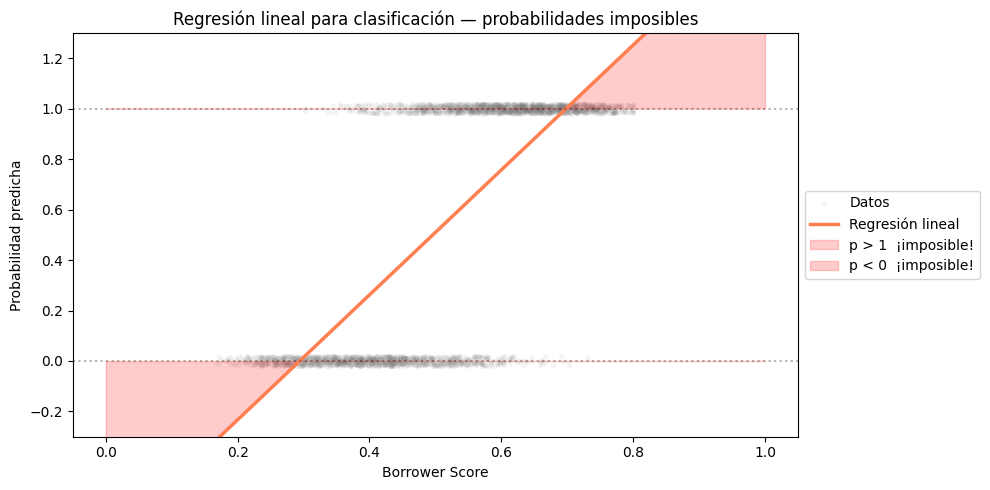

Para score=0.0 → p = -0.73  ← ¡negativo!
Para score=1.0 → p = 1.75  ← ¡mayor que 1!

→ La regresión lineal NO respeta los límites [0, 1]
→ Necesitamos una transformación que mantenga p entre 0 y 1


In [2]:
lin_reg = LinearRegression()
lin_reg.fit(X_score, y)

x_range = np.linspace(0, 1, 300).reshape(-1, 1)
y_pred_lin = lin_reg.predict(x_range)

fig, ax = plt.subplots(figsize=(10, 5))

jitter = rng.uniform(-0.02, 0.02, len(y))
ax.scatter(X_score.ravel(), y + jitter, alpha=0.06, s=8, c="gray", label="Datos")
ax.plot(x_range, y_pred_lin, color="coral", linewidth=2.5, label="Regresión lineal")

ax.axhline(0, color="k", linestyle=":", alpha=0.3)
ax.axhline(1, color="k", linestyle=":", alpha=0.3)
ax.fill_between(
    x_range.ravel(),
    1,
    np.maximum(y_pred_lin.ravel(), 1),
    alpha=0.2,
    color="red",
    label="p > 1  ¡imposible!",
)
ax.fill_between(
    x_range.ravel(),
    np.minimum(y_pred_lin.ravel(), 0),
    0,
    alpha=0.2,
    color="red",
    label="p < 0  ¡imposible!",
)

ax.set_xlabel("Borrower Score")
ax.set_ylabel("Probabilidad predicha")
ax.set_title("Regresión lineal para clasificación — probabilidades imposibles")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylim(-0.3, 1.3)
plt.tight_layout()
plt.show()

print(f"Para score=0.0 → p = {lin_reg.predict([[0.0]])[0]:.2f}  ← ¡negativo!")
print(f"Para score=1.0 → p = {lin_reg.predict([[1.0]])[0]:.2f}  ← ¡mayor que 1!")
print("\n→ La regresión lineal NO respeta los límites [0, 1]")
print("→ Necesitamos una transformación que mantenga p entre 0 y 1")

## 2 · Odds — las apuestas

Primer paso: cambiar de escala. En lugar de probabilidades, pensamos en **odds** (momios):

$$\text{Odds}(Y=1) = \frac{p}{1-p}$$

Si P(paid off) = 0.75 → Odds = 0.75 / 0.25 = **3.0** → "3 a 1 a favor de que pague"

| Probabilidad $p$ | Odds $\frac{p}{1-p}$ | Interpretación |
|:-:|:-:|:--|
| 0.10 | 0.11 | ~9 a 1 en contra |
| 0.50 | 1.00 | 50/50 — neutral |
| 0.75 | 3.00 | 3 a 1 a favor |
| 0.90 | 9.00 | 9 a 1 a favor |

Los odds van de $0$ a $+\infty$. Mejor que $[0, 1]$... ¡pero todavía no llegan a $-\infty$!

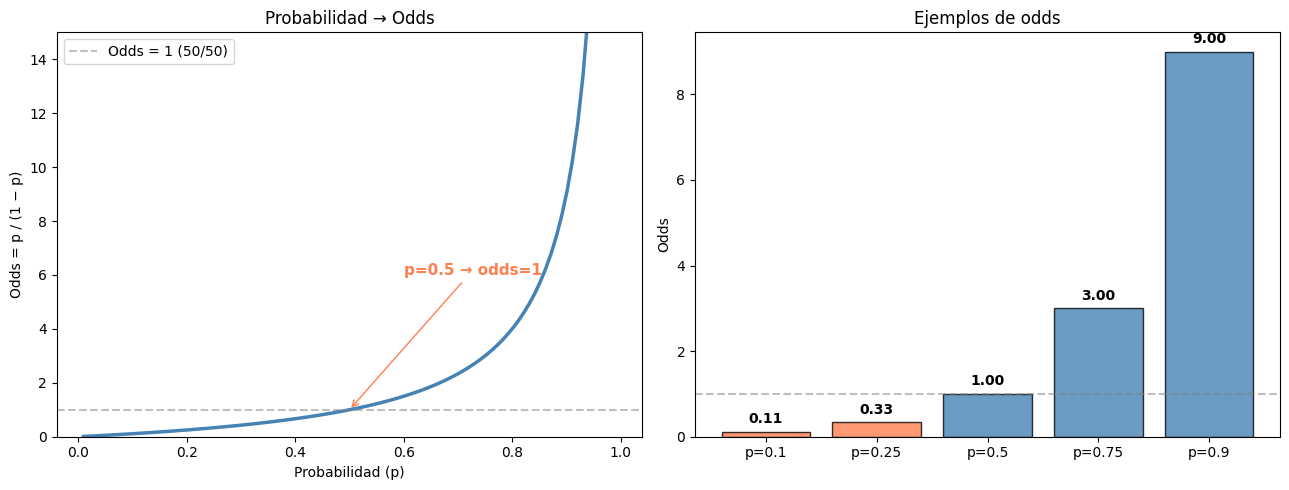

Odds = p / (1 − p)
→ Rango: [0, +∞)
→ odds > 1 → más probable que sí
→ odds < 1 → más probable que no
→ odds = 1 → 50/50


In [6]:
p = np.linspace(0.01, 0.99, 100)
odds = p / (1 - p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: curva p → odds
axes[0].plot(p, odds, color="steelblue", linewidth=2.5)
axes[0].axhline(1, color="gray", linestyle="--", alpha=0.5, label="Odds = 1 (50/50)")
axes[0].set_xlabel("Probabilidad (p)")
axes[0].set_ylabel("Odds = p / (1 − p)")
axes[0].set_title("Probabilidad → Odds")
axes[0].set_ylim(0, 15)
axes[0].legend()
axes[0].annotate(
    "p=0.5 → odds=1",
    xy=(0.5, 1),
    xytext=(0.6, 6),
    arrowprops=dict(arrowstyle="->", color="coral"),
    color="coral",
    fontsize=11,
    fontweight="bold",
)

# Panel 2: ejemplos concretos
ejemplos_p = [0.1, 0.25, 0.5, 0.75, 0.9]
ejemplos_odds = [pi / (1 - pi) for pi in ejemplos_p]
colors = ["coral" if o < 1 else "steelblue" for o in ejemplos_odds]

axes[1].bar(
    [f"p={pi}" for pi in ejemplos_p],
    ejemplos_odds,
    color=colors,
    edgecolor="k",
    alpha=0.8,
)
axes[1].axhline(1, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Odds")
axes[1].set_title("Ejemplos de odds")
for i, (pi, oi) in enumerate(zip(ejemplos_p, ejemplos_odds)):
    axes[1].text(i, oi + 0.2, f"{oi:.2f}", ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

print("Odds = p / (1 − p)")
print("→ Rango: [0, +∞)")
print("→ odds > 1 → más probable que sí")
print("→ odds < 1 → más probable que no")
print("→ odds = 1 → 50/50")

## 3 · Logit — de odds a log-odds

Segundo paso: tomar el **logaritmo** de los odds:

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$$

| $p$ | Odds | logit |
|:-:|:-:|:-:|
| 0.01 | 0.01 | −4.6 |
| 0.10 | 0.11 | −2.2 |
| 0.50 | 1.00 | 0.0 |
| 0.90 | 9.00 | +2.2 |
| 0.99 | 99.0 | +4.6 |

Ahora sí: logit mapea $(0, 1) \to (-\infty, +\infty)$.

¡**Ya podemos usar un modelo lineal** sobre el logit!

$$\text{logit}(p) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots$$

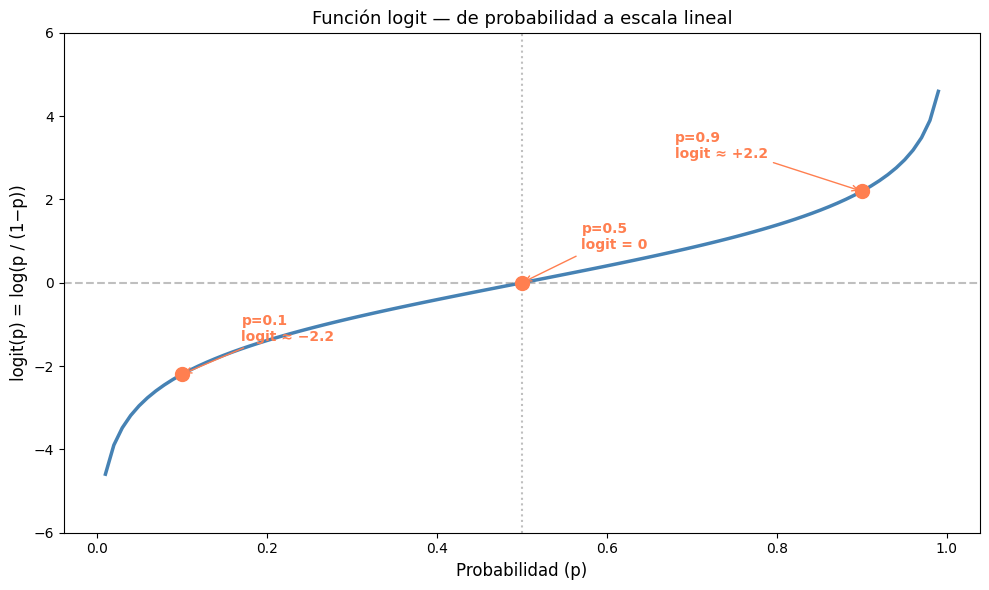

logit(p) = log(p / (1−p))
  logit(0.10) = -2.20
  logit(0.50) = +0.00
  logit(0.90) = +2.20

→ p = 0.5 → logit = 0  (punto neutral)
→ p → 0   → logit → −∞
→ p → 1   → logit → +∞


In [8]:
logit_vals = np.log(p / (1 - p))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p, logit_vals, color="steelblue", linewidth=2.5)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)

# Puntos clave
for pi, label in [(0.1, "logit ≈ −2.2"), (0.5, "logit = 0"), (0.9, "logit ≈ +2.2")]:
    li = np.log(pi / (1 - pi))
    ax.plot(pi, li, "o", color="coral", markersize=10, zorder=5)
    dx, dy = (0.07, 0.8) if pi < 0.9 else (-0.22, 0.8)
    ax.annotate(
        f"p={pi}\n{label}",
        xy=(pi, li),
        xytext=(pi + dx, li + dy),
        fontsize=10,
        color="coral",
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="coral"),
    )

ax.set_xlabel("Probabilidad (p)", fontsize=12)
ax.set_ylabel("logit(p) = log(p / (1−p))", fontsize=12)
ax.set_title("Función logit — de probabilidad a escala lineal", fontsize=13)
ax.set_ylim(-6, 6)
plt.tight_layout()
plt.show()

print("logit(p) = log(p / (1−p))")
print(f"  logit(0.10) = {np.log(0.1 / 0.9):+.2f}")
print(f"  logit(0.50) = {np.log(0.5 / 0.5):+.2f}")
print(f"  logit(0.90) = {np.log(0.9 / 0.1):+.2f}")
print("\n→ p = 0.5 → logit = 0  (punto neutral)")
print("→ p → 0   → logit → −∞")
print("→ p → 1   → logit → +∞")

## 4 · Función logística (*logistic response function*)

La función logística es la **inversa del logit**. Dado un valor $z$ (combinación lineal), devuelve una probabilidad:

$$p = \frac{1}{1 + e^{-z}}$$

Donde $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots$

La famosa **curva S** (sigmoid) garantiza que $p$ siempre quede entre 0 y 1.

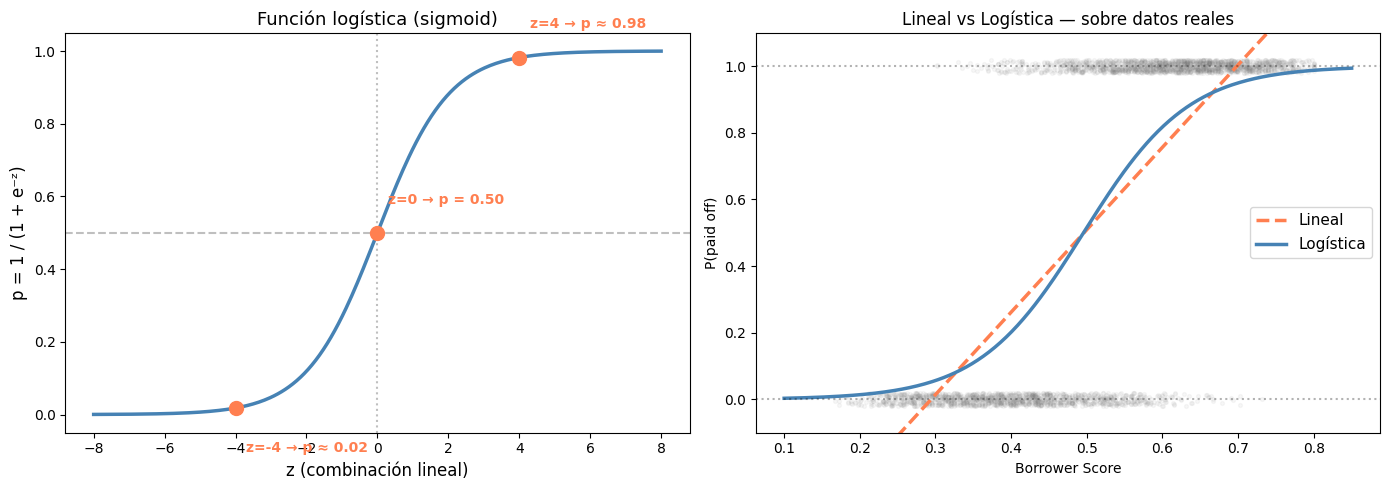

→ La sigmoid siempre queda entre 0 y 1
→ z = 0 es la frontera de decisión (p = 0.5)
→ La curva logística se ajusta mucho mejor a los datos binarios


In [9]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: La sigmoid
axes[0].plot(z, sigmoid, color="steelblue", linewidth=2.5)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(0, color="gray", linestyle=":", alpha=0.5)

for zi, pi_label in [(-4, "p ≈ 0.02"), (0, "p = 0.50"), (4, "p ≈ 0.98")]:
    pi = 1 / (1 + np.exp(-zi))
    axes[0].plot(zi, pi, "o", color="coral", markersize=10, zorder=5)
    dy = 0.08 if zi >= 0 else -0.12
    axes[0].annotate(
        f"z={zi} → {pi_label}",
        xy=(zi, pi),
        xytext=(zi + 0.3, pi + dy),
        fontsize=10,
        color="coral",
        fontweight="bold",
    )

axes[0].set_xlabel("z (combinación lineal)", fontsize=12)
axes[0].set_ylabel("p = 1 / (1 + e⁻ᶻ)", fontsize=12)
axes[0].set_title("Función logística (sigmoid)", fontsize=13)
axes[0].set_ylim(-0.05, 1.05)

# Panel 2: Lineal vs logística sobre datos reales
log_reg_1d = LogisticRegression()
log_reg_1d.fit(X_score, y)

x_plot = np.linspace(0.1, 0.85, 300).reshape(-1, 1)
y_lin = lin_reg.predict(x_plot)
y_log = log_reg_1d.predict_proba(x_plot)[:, 1]

jitter2 = rng.uniform(-0.02, 0.02, len(y))
axes[1].scatter(X_score.ravel(), y + jitter2, alpha=0.06, s=8, c="gray")
axes[1].plot(
    x_plot, y_lin, color="coral", linewidth=2.5, label="Lineal", linestyle="--"
)
axes[1].plot(x_plot, y_log, color="steelblue", linewidth=2.5, label="Logística")
axes[1].axhline(0, color="k", linestyle=":", alpha=0.3)
axes[1].axhline(1, color="k", linestyle=":", alpha=0.3)
axes[1].set_xlabel("Borrower Score")
axes[1].set_ylabel("P(paid off)")
axes[1].set_title("Lineal vs Logística — sobre datos reales")
axes[1].legend(fontsize=11)
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

print("→ La sigmoid siempre queda entre 0 y 1")
print("→ z = 0 es la frontera de decisión (p = 0.5)")
print("→ La curva logística se ajusta mucho mejor a los datos binarios")

## 5 · El círculo completo

La regresión logística conecta tres ideas:

| Paso | Transformación | Rango |
|:--:|:--|:--:|
| 1 | $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2$ | $(-\infty, +\infty)$ |
| 2 | $p = \frac{1}{1 + e^{-z}}$ | $(0, 1)$ |
| 3 | clase = *paid off* si $p > 0.5$ | \{0, 1\} |

O leyendo al revés:

$$\underbrace{\log\left(\frac{p}{1-p}\right)}_{\text{logit}} = \underbrace{\beta_0 + \beta_1 x_1 + \beta_2 x_2}_{\text{combinación lineal}}$$

Hagamos el cálculo paso a paso con valores inventados.

In [10]:
# Coeficientes inventados (razonables para loans)
beta_0 = -3.0  # intercepto
beta_1 = 8.0  # borrower_score  (positivo → más score → más prob paid off)
beta_2 = -0.3  # payment_inc_ratio (negativo → más ratio → menos prob)

# Escenario: score=0.6, ratio=8
score_ej, ratio_ej = 0.6, 8.0

# Paso 1: combinación lineal
z_ej = beta_0 + beta_1 * score_ej + beta_2 * ratio_ej
print("PASO 1 — Combinación lineal (z)")
print(f"  z = β₀ + β₁·score + β₂·ratio")
print(f"  z = {beta_0} + {beta_1}×{score_ej} + ({beta_2})×{ratio_ej}")
print(f"  z = {beta_0} + {beta_1 * score_ej} + ({beta_2 * ratio_ej})")
print(f"  z = {z_ej:.1f}")

# Paso 2: función logística
p_ej = 1 / (1 + np.exp(-z_ej))
print(f"\nPASO 2 — Función logística (p)")
print(f"  p = 1 / (1 + e^(−{z_ej:.1f}))")
print(f"  p = 1 / (1 + {np.exp(-z_ej):.4f})")
print(f"  p = {p_ej:.4f} ({p_ej:.1%})")

# Paso 3: clasificación
clase = "paid off" if p_ej > 0.5 else "default"
print(f"\nPASO 3 — Clasificación")
print(f"  p = {p_ej:.1%} {'>' if p_ej > 0.5 else '<'} 50% → {clase}")

# Verificación
odds_ej = p_ej / (1 - p_ej)
logit_ej = np.log(odds_ej)
print(f"\nVERIFICACIÓN (el círculo completo):")
print(f"  odds = p/(1−p) = {odds_ej:.4f}")
print(f"  logit = log(odds) = {logit_ej:.1f} ← ¡es z!")

PASO 1 — Combinación lineal (z)
  z = β₀ + β₁·score + β₂·ratio
  z = -3.0 + 8.0×0.6 + (-0.3)×8.0
  z = -3.0 + 4.8 + (-2.4)
  z = -0.6

PASO 2 — Función logística (p)
  p = 1 / (1 + e^(−-0.6))
  p = 1 / (1 + 1.8221)
  p = 0.3543 (35.4%)

PASO 3 — Clasificación
  p = 35.4% < 50% → default

VERIFICACIÓN (el círculo completo):
  odds = p/(1−p) = 0.5488
  logit = log(odds) = -0.6 ← ¡es z!


## 6 · Regresión logística con sklearn

Ahora ajustemos un modelo real con `LogisticRegression` sobre los datos de préstamos.

In [11]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

print("=== Regresión Logística ===")
print(f"Coeficientes:")
print(f"  β₁ (borrower_score):    {log_reg.coef_[0][0]:+.4f}")
print(f"  β₂ (payment_inc_ratio): {log_reg.coef_[0][1]:+.4f}")
print(f"Intercepto β₀:            {log_reg.intercept_[0]:+.4f}")
print(f"\nAccuracy: {log_reg.score(X, y):.1%}")

# Predicciones para escenarios concretos
print("\n--- Predicciones ---")
escenarios = pd.DataFrame(
    {
        "borrower_score": [0.7, 0.3, 0.5, 0.6],
        "payment_inc_ratio": [5.0, 15.0, 10.0, 3.0],
    }
)

probas = log_reg.predict_proba(escenarios.values)
for i, row in escenarios.iterrows():
    p_paid = probas[i, 1]
    clase = "paid off" if p_paid > 0.5 else "default"
    print(
        f"  score={row['borrower_score']}, ratio={row['payment_inc_ratio']:.0f} "
        f"→ P(paid off) = {p_paid:.1%} → {clase}"
    )

=== Regresión Logística ===
Coeficientes:
  β₁ (borrower_score):    +12.7612
  β₂ (payment_inc_ratio): -0.5003
Intercepto β₀:            -2.3847

Accuracy: 91.1%

--- Predicciones ---
  score=0.7, ratio=5 → P(paid off) = 98.3% → paid off
  score=0.3, ratio=15 → P(paid off) = 0.2% → default
  score=0.5, ratio=10 → P(paid off) = 26.8% → default
  score=0.6, ratio=3 → P(paid off) = 97.7% → paid off


## 7 · Interpretación: odds ratios

Los coeficientes $\beta$ del logit son difíciles de interpretar directamente. Pero $e^{\beta}$ tiene significado claro:

> Por cada unidad que sube $x_j$, los *odds* de paid off se **multiplican** por $e^{\beta_j}$

- $e^{\beta} > 1$ → el predictor **aumenta** los odds de la clase positiva
- $e^{\beta} < 1$ → el predictor **disminuye** los odds
- $e^{\beta} = 1$ → sin efecto

In [12]:
coefs = log_reg.coef_[0]

print("=== Odds Ratios ===\n")
for name, beta in zip(PREDICTORS, coefs):
    or_val = np.exp(beta)
    print(f"{name}:")
    print(f"  β = {beta:+.4f}")
    print(f"  e^β = {or_val:.4f}")
    if or_val > 1:
        print(f"  → +1 en {name} multiplica los odds de paid off por {or_val:.2f}")
    else:
        print(f"  → +1 en {name} multiplica los odds de paid off por {or_val:.4f}")
    print()

# Ejemplo práctico
print("--- Ejemplo práctico ---")
delta = 0.1
or_score = np.exp(coefs[0] * delta)
print(f"Si borrower_score sube 0.1:")
print(f"  odds se multiplican por e^({coefs[0]:.2f} × 0.1) = {or_score:.2f}")
print(
    f"  → Los odds de paid off {'suben' if or_score > 1 else 'bajan'} un {abs(or_score - 1) * 100:.0f}%"
)

=== Odds Ratios ===

borrower_score:
  β = +12.7612
  e^β = 348430.3490
  → +1 en borrower_score multiplica los odds de paid off por 348430.35

payment_inc_ratio:
  β = -0.5003
  e^β = 0.6064
  → +1 en payment_inc_ratio multiplica los odds de paid off por 0.6064

--- Ejemplo práctico ---
Si borrower_score sube 0.1:
  odds se multiplican por e^(12.76 × 0.1) = 3.58
  → Los odds de paid off suben un 258%


## 8 · Frontera de decisión: Logistic vs LDA

Tanto LDA como Regresión Logística producen una frontera **lineal** (recta). La diferencia:

| | LDA | Logistic Regression |
|:--|:--|:--|
| Supone | Datos gaussianos + misma covarianza | Solo que logit(p) es lineal |
| Estima | Medias + covarianza → frontera | Coeficientes β directamente (MLE) |
| Mejor cuando | Los datos son gaussianos | Los datos NO son gaussianos |

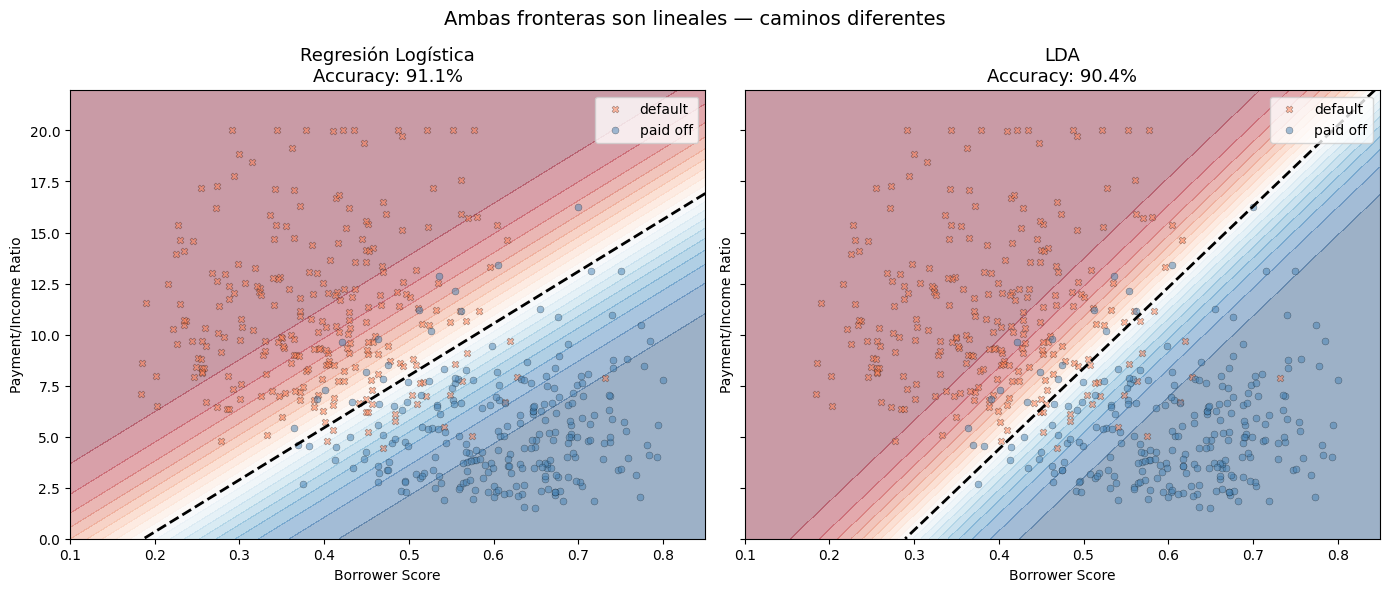

Accuracy Logistic Regression: 91.1%
Accuracy LDA:                 90.4%

→ Ambos modelos producen fronteras lineales muy similares
→ Logistic Regression es más usado en la práctica (menos supuestos)


In [13]:
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Subsample para scatter
idx = rng.choice(len(df), size=500, replace=False)

# Grid
x_min, x_max = 0.1, 0.85
y_min, y_max = 0, 22
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]

models = [("Regresión Logística", log_reg), ("LDA", lda)]

for ax, (name, model) in zip(axes, models):
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.4)
    ax.contour(xx, yy, Z, levels=[0.5], colors=["k"], linewidths=2, linestyles="--")

    for clase, val, color, marker in [
        ("default", 0, "coral", "X"),
        ("paid off", 1, "steelblue", "o"),
    ]:
        mask = y[idx] == val
        ax.scatter(
            X[idx][mask, 0],
            X[idx][mask, 1],
            c=color,
            marker=marker,
            s=25,
            alpha=0.5,
            edgecolors="k",
            linewidths=0.3,
            label=clase,
        )

    acc = model.score(X, y)
    ax.set_title(f"{name}\nAccuracy: {acc:.1%}", fontsize=13)
    ax.set_xlabel("Borrower Score")
    ax.set_ylabel("Payment/Income Ratio")
    ax.legend(loc="upper right")

plt.suptitle("Ambas fronteras son lineales — caminos diferentes", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Accuracy Logistic Regression: {log_reg.score(X, y):.1%}")
print(f"Accuracy LDA:                 {lda.score(X, y):.1%}")
print("\n→ Ambos modelos producen fronteras lineales muy similares")
print("→ Logistic Regression es más usado en la práctica (menos supuestos)")

## 9 · Resumen

| Concepto | Qué hace | Rango |
|:--|:--|:--:|
| Probabilidad $p$ | Lo que queremos predecir | $(0, 1)$ |
| Odds $= \frac{p}{1-p}$ | Ratio éxito/fracaso | $(0, +\infty)$ |
| Logit $= \log\left(\frac{p}{1-p}\right)$ | Escala lineal | $(-\infty, +\infty)$ |
| Función logística $= \frac{1}{1+e^{-z}}$ | De vuelta a probabilidad | $(0, 1)$ |

### El flujo completo

$$\text{predictores} \xrightarrow{\beta_0 + \beta_1 x_1 + \cdots} \underbrace{z}_{\text{logit}} \xrightarrow{1/(1+e^{-z})} \underbrace{p}_{\text{probabilidad}} \xrightarrow{p > 0.5?} \text{clase}$$

### Logistic Regression vs LDA

| | Logistic Regression | LDA |
|:--|:--|:--|
| Transforma | logit(p) = combinación lineal | Función discriminante |
| Asume | logit es lineal en predictores | Datos gaussianos + covarianza compartida |
| Estima | $\beta$ por máxima verosimilitud (*MLE*) | Medias + covarianza |
| Frontera | Lineal (recta) | Lineal (recta) |
| Más usado | En la práctica (menos supuestos) | Como baseline / datos gaussianos |

> 👉 En el siguiente notebook veremos cómo **ajustar y evaluar** modelos logísticos más a fondo.